In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from my_utils import *
big_figure()

In [3]:
data = np.loadtxt("SiPM_trace_UVlaser.csv",delimiter=",",skiprows=10)

x = data[:,0]
y = data[:,1]

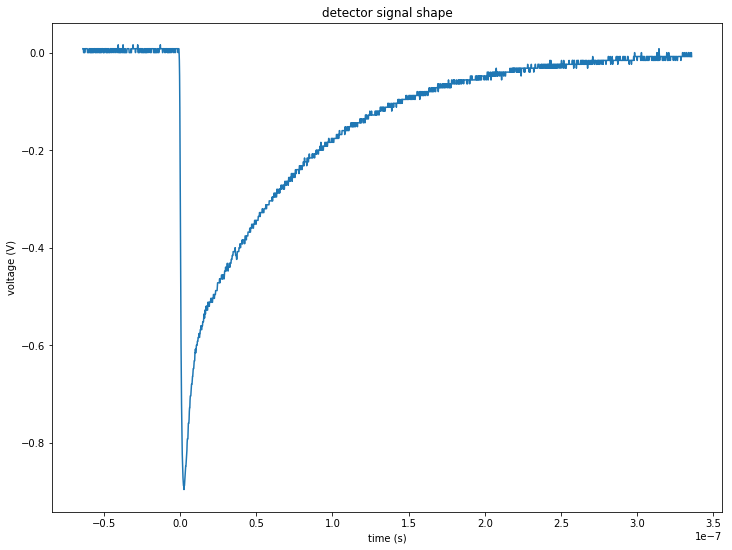

In [4]:
plt.plot(x,y)
plt.title("detector signal shape")
plt.xlabel("time (s)")
plt.ylabel("voltage (V)")
plt.show()

/workdir/python_modules/sigproc_kit.py:473: RuntimeWarning: overflow encountered in exp
  return (x_ > 0) * R*Q/(tau1-tau2) *(np.exp(-x_/tau1) - np.exp(-x_/tau2))


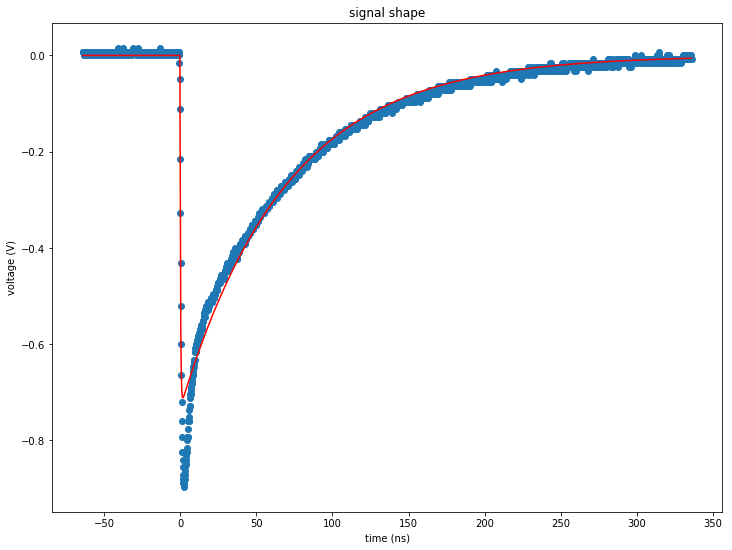

Q:     -1.014e-09
tau1:  3.636e-10
tau2:  6.930e-08
delay: -1.864e-10


In [5]:
from scipy.optimize import curve_fit

from sigproc_kit import * 


# no special delimiter needed for tsv
xdata = data[:,0]
ydata = data[:,1]

#plt.plot(xdata*1e9,ydata)

def func(x, Q, tau1, tau2, delay):
    return detector_signal_function(x, Q, tau1, tau2, delay)

popt, pcov = curve_fit(func, xdata, ydata, p0 = [-10e-12,1e-9,2e-9,10e-9])

plt.scatter(xdata*1e9,ydata)
plt.title("signal shape")
plt.xlabel("time (ns)")
plt.ylabel("voltage (V)")
plt.plot(xdata*1e9, func(xdata, *popt), 'r-')#,
#         label='fit: a=%5.3f, b=%5.3f, c=%5.3f, d=%5.3f' % tuple(popt))
#plt.legend()
plt.show()

print("Q:     {:3.3e}".format(popt[0]))
print("tau1:  {:3.3e}".format(popt[1]))
print("tau2:  {:3.3e}".format(popt[2]))
print("delay: {:3.3e}".format(popt[3]))

/workdir/python_modules/sigproc_kit.py:473: RuntimeWarning: invalid value encountered in multiply
  return (x_ > 0) * R*Q/(tau1-tau2) *(np.exp(-x_/tau1) - np.exp(-x_/tau2))


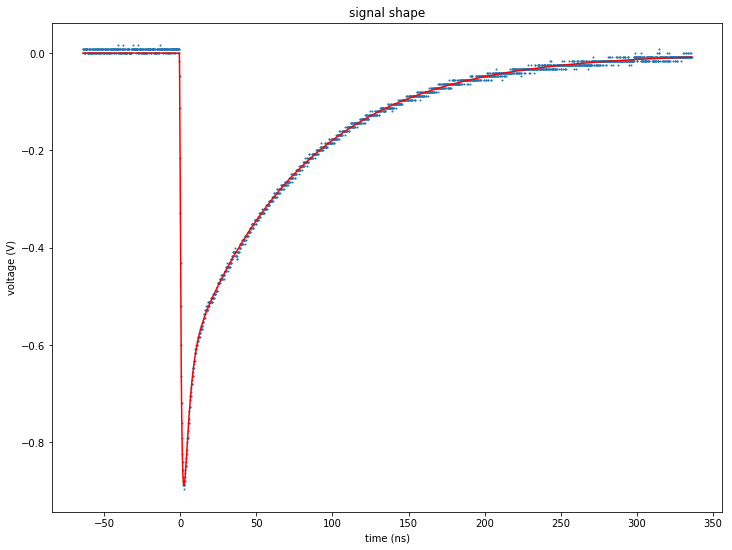

Q:     -9.935e-10
tau1:  1.446e-09
tau2:  7.651e-08
delay: -7.601e-11
Qb:     -4.540e-11
tau1b:  1.072e-09
tau2b:  3.080e-09
delayb: -4.740e-10


In [6]:

def func(x, Q, tau1, tau2, delay,Qb,tau1b,tau2b,delayb):
    return detector_signal_function(x, Q, tau1, tau2, delay) + detector_signal_function(x, Qb, tau1b, tau2b, delayb)

popt, pcov = curve_fit(func, xdata, ydata, p0 = list(popt)+[-0.5e-9,2e-10,3e-8,-1.86e-10])

plt.scatter(xdata*1e9,ydata,s=1)
plt.title("signal shape")
plt.xlabel("time (ns)")
plt.ylabel("voltage (V)")
plt.plot(xdata*1e9, func(xdata, *popt), 'r-')#,
#         label='fit: a=%5.3f, b=%5.3f, c=%5.3f, d=%5.3f' % tuple(popt))
#plt.legend()
plt.show()

print("Q:     {:3.3e}".format(popt[0]))
print("tau1:  {:3.3e}".format(popt[1]))
print("tau2:  {:3.3e}".format(popt[2]))
print("delay: {:3.3e}".format(popt[3]))
print("Qb:     {:3.3e}".format(popt[4]))
print("tau1b:  {:3.3e}".format(popt[5]))
print("tau2b:  {:3.3e}".format(popt[6]))
print("delayb: {:3.3e}".format(popt[7]))

In [10]:
popt[4]

-4.5396655077908563e-11

In [22]:
Qa      = popt[0]
tau1a   = popt[1]
tau2a   = popt[2]
delaya  = popt[3]
Qb     = popt[4]
tau1b  = popt[5]
tau2b  = popt[6]
delayb = popt[7]


delaya -= delayb
delayb -= delayb


print(".param Qa      {:3.3e}".format(Qa))
print(".param tau1a   {:3.3e}".format(tau1a))
print(".param tau2a   {:3.3e}".format(tau2a))
print(".param delaya  {:3.3e}".format(delaya))
print(".param Qb      {:3.3e}".format(Qb))
print(".param tau1b   {:3.3e}".format(tau1b))
print(".param tau2b   {:3.3e}".format(tau2b))
print(".param delayb  {:3.3e}".format(delayb))

#print(
#        "V=50*( Qa/(tau1a-tau2a)*(exp(-time/tau1a)-exp(-time/tau2a))".format(Qa,tau1a,tau2a,tau1a,tau2a)
#        +"+ Qb/(tau1b-tau2b)*(exp(-time/tau1b)-exp(-time/tau2b)) )".format(Qb,tau1b,tau2b,tau1b,tau2b)
#         )


print(
        "V=50*( (time>=delaya)*Qa/(tau1a-tau2a)*(exp(-(time-delaya)/tau1a)-exp(-(time-delaya)/tau2a))".format(Qa,tau1a,tau2a,tau1a,tau2a)
        +"+     (time>=delayb)*Qb/(tau1b-tau2b)*(exp(-(time-delayb)/tau1b)-exp(-(time-delayb)/tau2b)) )".format(Qb,tau1b,tau2b,tau1b,tau2b)
         )


.param Qa      -9.935e-10
.param tau1a   1.446e-09
.param tau2a   7.651e-08
.param delaya  3.980e-10
.param Qb      -4.540e-11
.param tau1b   1.072e-09
.param tau2b   3.080e-09
.param delayb  0.000e+00
V=50*( (time>=delaya)*Qa/(tau1a-tau2a)*(exp(-(time-delaya)/tau1a)-exp(-(time-delaya)/tau2a))+     (time>=delayb)*Qb/(tau1b-tau2b)*(exp(-(time-delayb)/tau1b)-exp(-(time-delayb)/tau2b)) )
